In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Electric: hourly kWh ---
elec1 = pd.read_csv("data/UsageData-01_01_2022-11_26_2024-clean.csv", parse_dates=["timestamp"])
elec2 = pd.read_csv("data/UsageData-11_27_2024-03_31_2026-clean.csv", parse_dates=["timestamp"])
elec2["timestamp"] = pd.to_datetime(elec2["timestamp"], utc=True).dt.tz_convert("America/New_York").dt.tz_localize(None)
elec = pd.concat([elec1, elec2], ignore_index=True).sort_values("timestamp").reset_index(drop=True)

# --- Meteorological: hourly observations ---
# wdir excluded — circular mean is misleading at daily scale
WEATHER_COLS = ["temp", "rhum", "prcp", "wspd", "pres", "wdir"]
met1 = pd.read_csv("data/meteorological_observations_1_1_2022-11_24_2024.csv", parse_dates=["time"], usecols=["time"] + WEATHER_COLS)
met2 = pd.read_csv("data/meteorological_observations_11_27_2024-3_31_2026.csv", parse_dates=["time"], usecols=["time"] + WEATHER_COLS)
met = pd.concat([met1, met2], ignore_index=True).sort_values("time").reset_index(drop=True)

# --- Merge on hour, then resample to daily ---
df_hourly = pd.merge(elec.rename(columns={"timestamp": "time"}), met, on="time", how="inner")
df_hourly = df_hourly.sort_values("time").reset_index(drop=True)

df = (
    df_hourly.set_index("time")
    .resample("D")
    .agg(
        kwh=("kwh", "sum"),
        temp=("temp", "mean"),
        temp_min=("temp", "min"),
        temp_max=("temp", "max"),
        rhum=("rhum", "mean"),
        prcp=("prcp", "sum"),   # total daily precipitation
        wspd=("wspd", "mean"),
        pres=("pres", "mean"),
        wdir=("wdir", "mean")
    )
    .reset_index()
)

print(f"Daily range: {df['time'].min().date()} → {df['time'].max().date()}")
print(f"Rows: {len(df):,}  |  Columns: {list(df.columns)}")
df.head()

Daily range: 2022-01-01 → 2026-03-31
Rows: 1,551  |  Columns: ['time', 'kwh', 'temp', 'rhum', 'prcp', 'wspd', 'pres', 'wdir']


,time,kwh,temp,rhum,prcp,wspd,pres,wdir
0,2022-01-01,34.262,2.575000,98.666667,3.6,0.283333,1012.554167,4.250
1,2022-01-02,47.032,2.691667,96.833333,1.4,3.175000,1003.237500,77.750
2,2022-01-03,48.584,-5.370833,63.666667,0.0,5.866667,1018.412500,156.750
3,2022-01-04,56.612,-9.304167,57.333333,0.0,5.308333,1024.845833,171.000
4,2022-01-05,43.300,-2.520833,91.458333,5.9,3.250000,1018.620833,69.625


In [3]:
# --- Time features (no year, no hour) ---
df["dayofweek"]  = df["time"].dt.dayofweek   # 0=Mon … 6=Sun
df["month"]      = df["time"].dt.month

# --- HDD (base 65°F, same calc as regression notebook) ---
df["temp_f"] = df["temp"] * 9 / 5 + 32
df["hdd"]    = np.maximum(0, 65 - df["temp_f"])

# --- Lag features ---
df["temp_yesterday"] = df["temp"].shift(1)                    # yesterday's avg temp
df["temp_3day"]      = df["temp"].shift(1).rolling(3).mean()  # 3-day lagged rolling avg
df["hdd_yesterday"]  = df["hdd"].shift(1)
df["hdd_3day"]       = df["hdd"].shift(1).rolling(3).mean()
df["kwh_yesterday"]  = df["kwh"].shift(1)

# Drop days with missing weather values
n_rows = len(df.index)
df = df.dropna(axis=0)
print(f'Dropped: {(n_rows - len(df.index))/n_rows:0.2%} of rows')
df.head()

Dropped: 0.52% of rows


,time,kwh,temp,rhum,prcp,wspd,pres,wdir,dayofweek,month,temp_f,hdd,temp_yesterday,temp_3day,hdd_yesterday,hdd_3day,kwh_yesterday
3,2022-01-04,56.612,-9.304167,57.333333,0.0,5.308333,1024.845833,171.000000,1,1,15.2525,49.7475,-5.370833,-0.034722,42.6675,33.0625,48.584
4,2022-01-05,43.300,-2.520833,91.458333,5.9,3.250000,1018.620833,69.625000,2,1,27.4625,37.5375,-9.304167,-3.994444,49.7475,40.1900,56.612
5,2022-01-06,25.369,1.837500,87.666667,0.0,3.400000,1005.254167,111.875000,3,1,35.3075,29.6925,-2.520833,-5.731944,37.5375,43.3175,43.300
6,2022-01-07,39.226,-2.383333,88.958333,7.4,5.375000,1008.795833,130.916667,4,1,27.7100,37.2900,1.837500,-3.329167,29.6925,38.9925,25.369
7,2022-01-08,83.615,-6.316667,61.166667,0.0,8.791667,1022.991667,250.708333,5,1,20.6300,44.3700,-2.383333,-1.022222,37.2900,34.8400,39.226


In [4]:
import numpy as np

def cyclical_encode(values, period):
    sin = np.sin(2 * np.pi * values / period)
    cos = np.cos(2 * np.pi * values / period)
    return sin, cos

df["dayofweek_sin"], df["dayofweek_cos"] = cyclical_encode(df["dayofweek"], 7)
df["month_sin"],     df["month_cos"]     = cyclical_encode(df["month"], 12)
df["wdir_sin"], df["wdir_cos"] = cyclical_encode(df["wdir"],360)

In [5]:
FEATURE_COLS = [
    'temp', 
    'temp_yesterday',
    'temp_3day',
    'hdd',
    'hdd_yesterday',
    'hdd_3day',
    'rhum', 
    'prcp', 
    'wspd',
    'kwh_yesterday'
    #'pres',
    #'dayofweek_sin', 'dayofweek_cos',
    #'month_sin', 'month_cos', 
    #"wdir_sin", "wdir_cos"
]

TARGET_COL   = "kwh"

print(df[FEATURE_COLS].describe())

X = df[FEATURE_COLS].values
y = df[TARGET_COL].values

split_idx = int(len(X) * 0.75)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

scaler_X = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train)
X_test_s  = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_s = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test_s  = scaler_y.fit_transform(y_test.reshape(-1, 1))

print(f"Features:      {FEATURE_COLS}")
print(f"X_train shape: {X_train_s.shape}")
print(f"X_test shape:  {X_test_s.shape}")
print(f"y_train shape: {y_train_s.shape}  (mean={y_train.mean():.3f} kWh, std={y_train.std():.3f})")
print(f"y_test  shape: {y_test_s.shape}  (mean={y_test.mean():.3f} kWh, std={y_test.std():.3f})")

              temp  temp_yesterday    temp_3day          hdd  hdd_yesterday  \
count  1543.000000     1543.000000  1543.000000  1543.000000    1543.000000   
mean      8.376747        8.367212     8.362378    19.006127      19.023290   
std       9.785513        9.792303     9.512992    16.173283      16.185441   
min     -21.775000      -21.775000   -14.152778     0.000000       0.000000   
25%       0.791667        0.787500     0.964825     2.467500       2.467500   
50%       8.479167        8.479167     8.101389    17.737500      17.737500   
75%      16.962500       16.962500    16.830556    31.575000      31.582500   
max      28.266667       28.266667    26.902778    72.195000      72.195000   

          hdd_3day         rhum         prcp         wspd  kwh_yesterday  
count  1543.000000  1543.000000  1543.000000  1543.000000    1543.000000  
mean     19.031992    71.767015     2.676604     6.194449      36.230719  
std      15.685751    13.203254     7.678983     3.732834      

In [6]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Convert to tensors
X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
y_train_t = torch.tensor(y_train_s, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_s, dtype=torch.float32)
y_test_t  = torch.tensor(y_test_s, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)

# Model
class MLP(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 64),  # input layer: n_features → 12 neurons
            nn.ReLU(),                  # activation: zero out negatives
            nn.Dropout(0.2),            # randomly zero 20% of neurons during training (regularization)
            nn.Linear(64, 32),          # hidden layer: 64 → 32 neurons
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)            # output layer: 32 → 1 (predicted kWh)
        )
    
    def forward(self, x):
        return self.net(x)              # forward pass: input flows through all layers sequentially


In [7]:
model = MLP(X_train_t.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=20, factor=0.5)
criterion = nn.MSELoss()                                    # loss function: mean squared error

train_losses = []
test_losses = []

n_epochs = 250
for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0
    for Xb, yb in train_loader:
        pred = model(Xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(train_loader))
    
    model.eval()
    with torch.no_grad():
        test_loss = criterion(model(X_test_t), y_test_t).item()
    test_losses.append(test_loss)
    scheduler.step(test_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | Test MSE: {test_loss:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")


Epoch  10 | Test MSE: 0.1908 | LR: 0.001000
Epoch  20 | Test MSE: 0.1718 | LR: 0.001000
Epoch  30 | Test MSE: 0.1588 | LR: 0.001000
Epoch  40 | Test MSE: 0.1580 | LR: 0.001000
Epoch  50 | Test MSE: 0.1608 | LR: 0.001000
Epoch  60 | Test MSE: 0.1545 | LR: 0.001000
Epoch  70 | Test MSE: 0.1552 | LR: 0.001000
Epoch  80 | Test MSE: 0.1520 | LR: 0.001000
Epoch  90 | Test MSE: 0.1486 | LR: 0.001000
Epoch 100 | Test MSE: 0.1697 | LR: 0.001000
Epoch 110 | Test MSE: 0.1528 | LR: 0.001000
Epoch 120 | Test MSE: 0.1547 | LR: 0.001000
Epoch 130 | Test MSE: 0.1630 | LR: 0.000500
Epoch 140 | Test MSE: 0.1554 | LR: 0.000500
Epoch 150 | Test MSE: 0.1586 | LR: 0.000500
Epoch 160 | Test MSE: 0.1539 | LR: 0.000250
Epoch 170 | Test MSE: 0.1535 | LR: 0.000250
Epoch 180 | Test MSE: 0.1564 | LR: 0.000125
Epoch 190 | Test MSE: 0.1554 | LR: 0.000125
Epoch 200 | Test MSE: 0.1566 | LR: 0.000063
Epoch 210 | Test MSE: 0.1553 | LR: 0.000063
Epoch 220 | Test MSE: 0.1556 | LR: 0.000031
Epoch 230 | Test MSE: 0.1556 | L

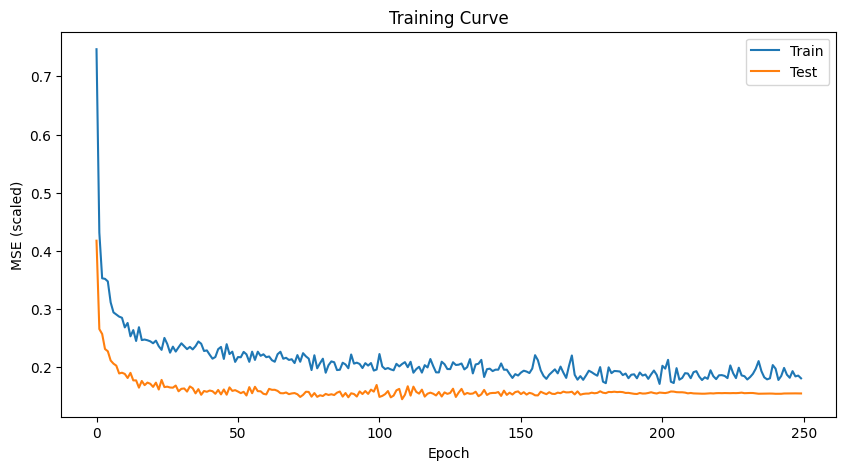

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train')
plt.plot(test_losses, label='Test')
plt.xlabel('Epoch')
plt.ylabel('MSE (scaled)')
plt.legend()
plt.title('Training Curve')
plt.show()

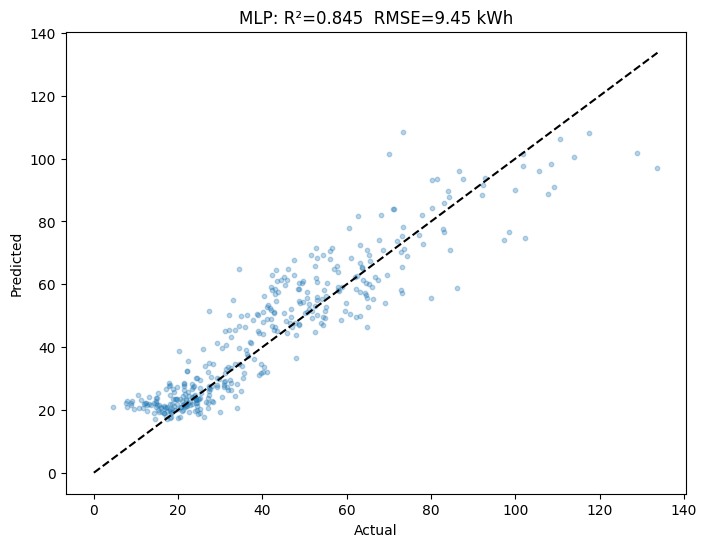

In [9]:
model.eval()
with torch.no_grad():
    pred_scaled = model(X_test_t).numpy()
    pred_kwh = scaler_y.inverse_transform(pred_scaled)

from sklearn.metrics import mean_squared_error, r2_score
rmse = np.sqrt(mean_squared_error(y_test, pred_kwh))
r2 = r2_score(y_test, pred_kwh)


plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred_kwh, alpha=0.3, s=10)
plt.plot([0, y_test.max()], [0, y_test.max()], 'k--')  # perfect prediction line
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(f'MLP: R²={r2:.3f}  RMSE={rmse:.2f} kWh')
plt.show()